# Credit Card Fraud Detection: Complete Pipeline
**Goal:** Build an end-to-end fraud detection model, handle severe class imbalance, train multiple models, and evaluate with appropriate metrics.

---

## Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


print(" Libraries imported successfully")

 Libraries imported successfully


---
# PHASE 1: DATA EXPLORATION & UNDERSTANDING

**Objectives:**
- Load and inspect the dataset
- Understand class distribution (imbalance severity)
- Analyze features and detect missing values
- Visualize the problem

In [16]:
df = pd.read_csv('creditcard.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (284807, 31)

First few rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
print("Dataset Info:")
print(df.info())
print(f"\nMissing values:\n{df.isnull().sum().sum()} total missing values")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

In [18]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [19]:
print("\n" + "="*60)
print("CLASS DISTRIBUTION - IMBALANCE SEVERITY")
print("="*60)

class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(f"\nClass 0 (Legitimate):  {class_counts[0]:,} transactions ({class_pct[0]:.2f}%)")
print(f"Class 1 (Fraud):       {class_counts[1]:,} transactions ({class_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: {class_counts[0]/class_counts[1]:.1f}:1 (legitimate:fraud)")
print(f"\nProblem: {class_pct[1]:.3f}% of transactions are fraud - SEVERELY IMBALANCED")
print("This means accuracy can be 99%+ by just predicting 'No Fraud' on everything!")


CLASS DISTRIBUTION - IMBALANCE SEVERITY

Class 0 (Legitimate):  284,315 transactions (99.83%)
Class 1 (Fraud):       492 transactions (0.17%)

Imbalance Ratio: 577.9:1 (legitimate:fraud)

Problem: 0.173% of transactions are fraud - SEVERELY IMBALANCED
This means accuracy can be 99%+ by just predicting 'No Fraud' on everything!


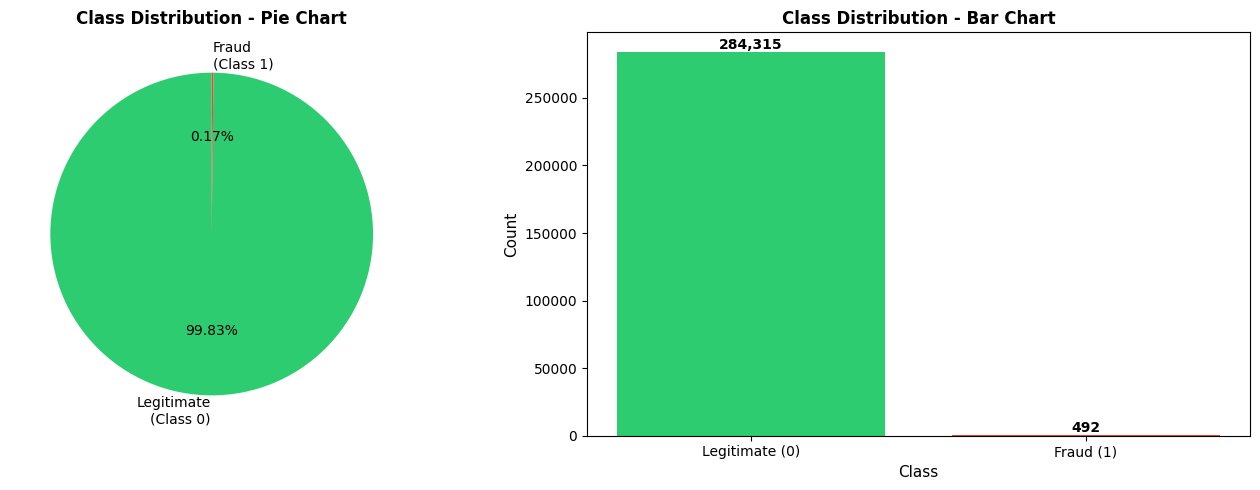

 Class imbalance clearly visualized - this is the main challenge!


In [20]:
fig , axes =plt.subplots(1,2,figsize=(14,5))

axes[0].pie(class_counts.values, labels=['Legitimate\n(Class 0)', 'Fraud\n(Class 1)'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Class Distribution - Pie Chart', fontsize=12, fontweight='bold')

axes[1].bar(class_counts.index, class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Class Distribution - Bar Chart', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Class imbalance clearly visualized - this is the main challenge!")

In [21]:
# Feature analysis
print("\n" + "="*60)
print("FEATURE OVERVIEW")
print("="*60)
print(f"\nTotal features: {df.shape[1] - 1} (excluding target 'Class')")
print(f"Feature types:")
print(f"  - V1 to V28: PCA-transformed features (anonymized)")
print(f"  - Amount: Transaction amount (in USD)")
print(f"  - Time: Seconds elapsed since first transaction")
print(f"\nAmount stats (non-fraud vs fraud):")
print(df.groupby('Class')['Amount'].describe())


FEATURE OVERVIEW

Total features: 30 (excluding target 'Class')
Feature types:
  - V1 to V28: PCA-transformed features (anonymized)
  - Amount: Transaction amount (in USD)
  - Time: Seconds elapsed since first transaction

Amount stats (non-fraud vs fraud):
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


---
# PHASE 2: DATA PREPROCESSING & FEATURE ENGINEERING

**Objectives:**
- Scale numerical features
- Perform correlation analysis
- Select important features
- Create stratified train-test split

In [22]:
from sklearn.preprocessing import StandardScaler


df_processed = df.copy()


numerical_features = [col for col in df.columns if col.startswith('V')] + ['Amount', 'Time']

print(f"Numerical features to scale: {len(numerical_features)}")
print(f"\nBefore scaling - Amount stats:")
print(f"  Min: {df['Amount'].min():.2f}")
print(f"  Max: {df['Amount'].max():.2f}")
print(f"  Mean: {df['Amount'].mean():.2f}")


scaler = StandardScaler()
df_processed[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

print(f"\nAfter scaling - Amount stats:")
print(f"  Min: {df_processed['Amount'].min():.4f}")
print(f"  Max: {df_processed['Amount'].max():.4f}")
print(f"  Mean: {df_processed['Amount'].mean():.4f}")
print(f"  Std: {df_processed['Amount'].std():.4f}")
print("\n Features scaled successfully (mean≈0, std≈1)")

Numerical features to scale: 30

Before scaling - Amount stats:
  Min: 0.00
  Max: 25691.16
  Mean: 88.35

After scaling - Amount stats:
  Min: -0.3532
  Max: 102.3622
  Mean: -0.0000
  Std: 1.0000

 Features scaled successfully (mean≈0, std≈1)


In [23]:
print("Computing correlation matrix...")
corr_matrix = df_processed.corr()

class_corr = corr_matrix['Class'].sort_values(ascending=True)
print(f"\nTop 10 features by correlation with Class (Fraud):")
print(class_corr.head(20)) 



Computing correlation matrix...

Top 10 features by correlation with Class (Fraud):
V17    -0.326481
V14    -0.302544
V12    -0.260593
V10    -0.216883
V16    -0.196539
V3     -0.192961
V7     -0.187257
V18    -0.111485
V1     -0.101347
V9     -0.097733
V5     -0.094974
V6     -0.043643
Time   -0.012323
V24    -0.007221
V13    -0.004570
V15    -0.004223
V23    -0.002685
V22     0.000805
V25     0.003308
V26     0.004455
Name: Class, dtype: float64


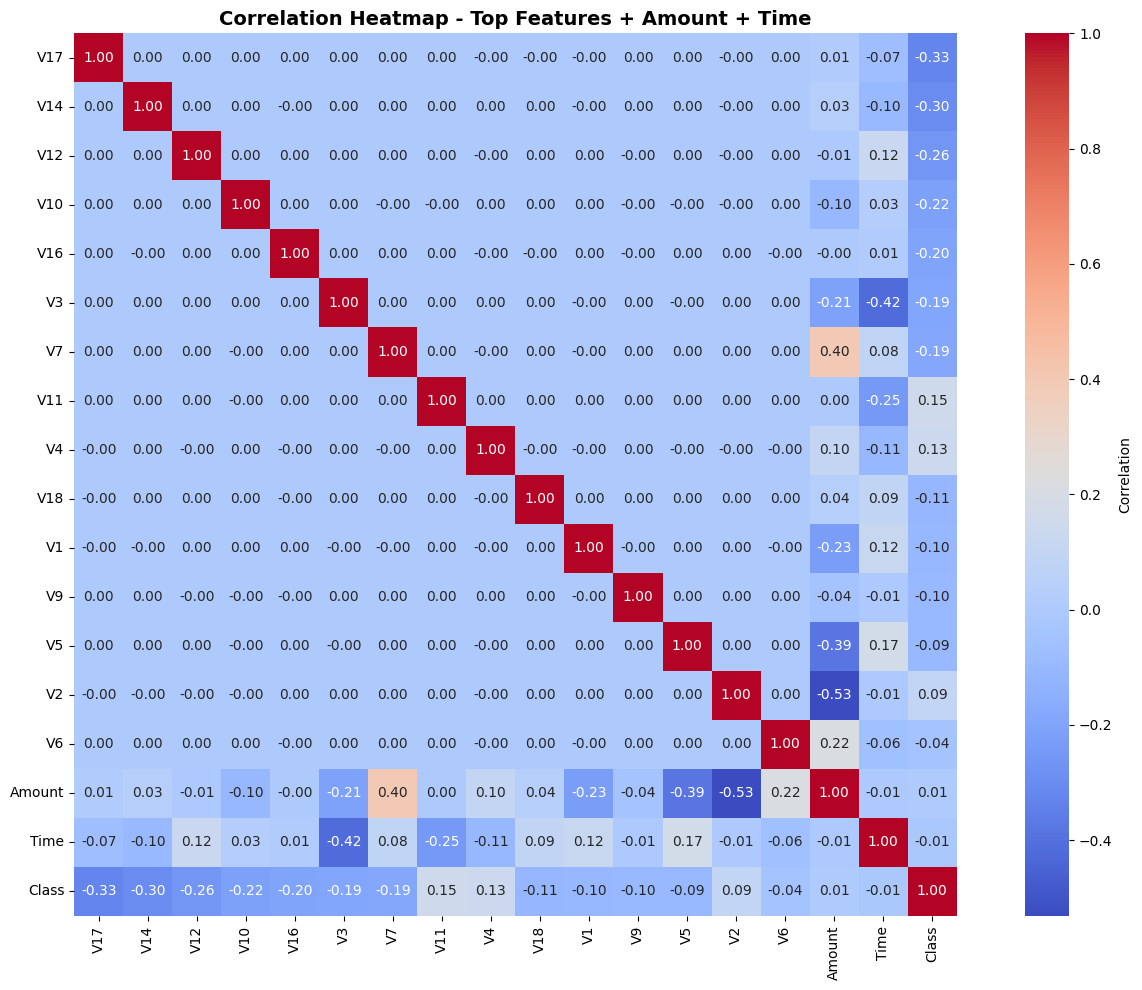


 Heatmap shows feature relationships and correlation with fraud


In [24]:
top_features = class_corr.drop('Class').abs().nlargest(15).index.tolist()
features_to_plot = top_features + ['Amount', 'Time', 'Class']

plt.figure(figsize=(14, 10))
sns.heatmap(df_processed[features_to_plot].corr(), annot=True, cmap='coolwarm', 
            fmt='.2f', cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Correlation Heatmap - Top Features + Amount + Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Heatmap shows feature relationships and correlation with fraud")

In [25]:
top_k_features = 20
selected_features = class_corr.drop('Class').abs().nlargest(top_k_features).index.tolist()

print(f"Selected {top_k_features} features with highest correlation to fraud:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat:4s} (correlation: {class_corr[feat]:+.4f})")

X = df_processed[selected_features].copy()
y = df_processed['Class'].copy()

print(f"\n Feature selection complete: X shape = {X.shape}, y shape = {y.shape}")

Selected 20 features with highest correlation to fraud:
   1. V17  (correlation: -0.3265)
   2. V14  (correlation: -0.3025)
   3. V12  (correlation: -0.2606)
   4. V10  (correlation: -0.2169)
   5. V16  (correlation: -0.1965)
   6. V3   (correlation: -0.1930)
   7. V7   (correlation: -0.1873)
   8. V11  (correlation: +0.1549)
   9. V4   (correlation: +0.1334)
  10. V18  (correlation: -0.1115)
  11. V1   (correlation: -0.1013)
  12. V9   (correlation: -0.0977)
  13. V5   (correlation: -0.0950)
  14. V2   (correlation: +0.0913)
  15. V6   (correlation: -0.0436)
  16. V21  (correlation: +0.0404)
  17. V19  (correlation: +0.0348)
  18. V20  (correlation: +0.0201)
  19. V8   (correlation: +0.0199)
  20. V27  (correlation: +0.0176)

 Feature selection complete: X shape = (284807, 20), y shape = (284807,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT (Stratified)")
print("="*60)
print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"  - Class 0 (Legitimate): {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"  - Class 1 (Fraud):      {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

print(f"\nTest set: {X_test.shape[0]:,} samples")
print(f"  - Class 0 (Legitimate): {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"  - Class 1 (Fraud):      {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

print(f"\n Stratified split maintains class balance in both train & test sets")
print(f"   Test set kept IMBALANCED to simulate real-world deployment")


TRAIN-TEST SPLIT (Stratified)

Training set: 227,845 samples
  - Class 0 (Legitimate): 227,451 (99.83%)
  - Class 1 (Fraud):      394 (0.17%)

Test set: 56,962 samples
  - Class 0 (Legitimate): 56,864 (99.83%)
  - Class 1 (Fraud):      98 (0.17%)

 Stratified split maintains class balance in both train & test sets
   Test set kept IMBALANCED to simulate real-world deployment


---
# PHASE 3: HANDLE CLASS IMBALANCE

**Objectives:**
- Quantify the imbalance problem
- Apply SMOTE (Synthetic Minority Oversampling Technique)
- Verify balanced training data

In [27]:
print("\n" + "="*60)
print("IMBALANCE PROBLEM QUANTIFICATION")
print("="*60)

fraud_train = (y_train == 1).sum()
legit_train = (y_train == 0).sum()
imbalance_ratio = legit_train / fraud_train

print(f"\n Training Set Imbalance:")
print(f"  Legitimate: {legit_train:,}")
print(f"  Fraud:      {fraud_train:,}")
print(f"  Ratio:      {imbalance_ratio:.1f}:1 (legit:fraud)")

print(f"\n PROBLEM: Simple accuracy-focused models will predict 'No Fraud' for everything")
print(f"   and achieve {legit_train/(legit_train+fraud_train)*100:.2f}% accuracy!")
print(f"\n SOLUTION: Use SMOTE to balance the training data")


IMBALANCE PROBLEM QUANTIFICATION

 Training Set Imbalance:
  Legitimate: 227,451
  Fraud:      394
  Ratio:      577.3:1 (legit:fraud)

 PROBLEM: Simple accuracy-focused models will predict 'No Fraud' for everything
   and achieve 99.83% accuracy!

 SOLUTION: Use SMOTE to balance the training data


In [28]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

print(f"\nApplying SMOTE to training data...")
print(f"Before SMOTE: {Counter(y_train)}")

smote = BorderlineSMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {Counter(y_train_resampled)}")
print(f"\n Training data now balanced:")
print(f"   Before: {Counter(y_train)}")
print(f"   After:  {Counter(y_train_resampled)}")
print(f"   New shape: {X_train_resampled.shape[0]:,} samples (added {y_train_resampled.sum() - y_train.sum():,} synthetic fraud samples)")

print(f"\n  IMPORTANT: Test set remains UNCHANGED and IMBALANCED")
print(f"   This reflects real-world data distribution for honest evaluation")


Applying SMOTE to training data...
Before SMOTE: Counter({0: 227451, 1: 394})
After SMOTE:  Counter({0: 227451, 1: 227451})

 Training data now balanced:
   Before: Counter({0: 227451, 1: 394})
   After:  Counter({0: 227451, 1: 227451})
   New shape: 454,902 samples (added 227,057 synthetic fraud samples)

  IMPORTANT: Test set remains UNCHANGED and IMBALANCED
   This reflects real-world data distribution for honest evaluation


---
# PHASE 4: TRAIN MULTIPLE MODELS

**Models:**
1. **Logistic Regression** — baseline, interpretable
2. **Random Forest** — feature importance, handles non-linearity
3. **XGBoost** — powerful gradient boosting, best performance

All trained on resampled (balanced) training data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {}


# 1. Logistic Regression
models['LogisticRegression'] = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
models['LogisticRegression'].fit(X_train_resampled, y_train_resampled)


# 2. Random Forest
models['RandomForest'] = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1
)
models['RandomForest'].fit(X_train_resampled, y_train_resampled)


# 3. XGBoost
scale_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()
models['XGBoost'] = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
models['XGBoost'].fit(X_train_resampled, y_train_resampled)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [30]:
# --- save all trained models to disk ---------------------------------------
import os
import joblib

# 1️⃣ تأكد من وجود فولدر لحفظ الموديلات
os.makedirs("models", exist_ok=True)

# 2️⃣ احفظ كل موديل بصيغة .pkl
for name, model in models.items():
    file_path = os.path.join("models", f"{name}.pkl")
    joblib.dump(model, file_path)
    print(f"Saved {name} to {file_path}")

print("✅ All models saved successfully!")

Saved LogisticRegression to models\LogisticRegression.pkl
Saved RandomForest to models\RandomForest.pkl
Saved XGBoost to models\XGBoost.pkl
✅ All models saved successfully!


In [31]:
# Training set performance (on resampled data)
print("\n" + "="*60)
print("TRAINING SET SCORES (Resampled Data)")
print("="*60)

train_scores = {}
for model_name, model in models.items():
    score = model.score(X_train_resampled, y_train_resampled)
    train_scores[model_name] = score
    print(f"{model_name:20s}: {score:.4f}")

print("\n  High training scores are expected (data is balanced)")


TRAINING SET SCORES (Resampled Data)
LogisticRegression  : 0.9873
RandomForest        : 0.9997
XGBoost             : 1.0000

  High training scores are expected (data is balanced)


In [32]:
# Test set performance (on original data)
print("\n" + "="*60)
print("TEST SET SCORES (Original Imbalanced Data)")
print("="*60)

test_scores = {}
for model_name, model in models.items():
    score = model.score(X_test, y_test)  
    test_scores[model_name] = score
    print(f"{model_name:20s}: {score:.4f}")

print("\n  Note: Scores are usually lower than training on resampled data due to class imbalance.")


TEST SET SCORES (Original Imbalanced Data)
LogisticRegression  : 0.9868
RandomForest        : 0.9991
XGBoost             : 0.9994

  Note: Scores are usually lower than training on resampled data due to class imbalance.
XGBoost             : 0.9994

  Note: Scores are usually lower than training on resampled data due to class imbalance.


---
# PHASE 5: EVALUATE & COMPARE MODELS

**Evaluation Strategy:**
- Confusion Matrix, Precision, Recall, F1 Score
- 5-fold stratified cross-validation
- Model comparison table

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, precision_score,
    recall_score
)


print("\n" + "="*80)
print("DETAILED MODEL EVALUATION ON TEST SET (Imbalanced, Real-World Distribution)")
print("="*80)

results = []
predictions = {}
predictions_proba = {}

for model_name, model in models.items():
    
    print(f"\n{'='*80}")
    print(f" {model_name.upper()}")
    print(f"{'='*80}")
    
    # Predictions       
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred
    
    # Probability predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    if hasattr(model, 'predict_proba'):
        predictions_proba[model_name] = y_pred_proba

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives (TN):  {tn:6,}  | False Positives (FP): {fp:6,}")
    print(f"  False Negatives (FN): {fn:6,}  | True Positives (TP):  {tp:6,}")
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    
    print(f"\nPerformance Metrics:")
    print(f"  Precision: {precision:.4f}  (of predicted fraud, how many are actual fraud?)")
    print(f"  Recall:    {recall:.4f}  (of actual fraud, how many did we catch?)")
    print(f"  F1 Score:  {f1:.4f}  (harmonic mean - primary metric for imbalanced data)")
    print(f"  Test Acc:  {model.score(X_test, y_test):.4f}  (NOT the main metric for imbalanced data)")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    
    results.append({
        'Model': model_name,
        'Train Score': train_scores[model_name],
        'Test Accuracy': model.score(X_test, y_test),
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("QUICK COMPARISON TABLE")
print("="*80)
print(results_df[['Model', 'Precision', 'Recall', 'F1 Score']].to_string(index=False))


DETAILED MODEL EVALUATION ON TEST SET (Imbalanced, Real-World Distribution)

 LOGISTICREGRESSION

Confusion Matrix:
  True Negatives (TN):  56,125  | False Positives (FP):    739
  False Negatives (FN):     11  | True Positives (TP):      87

Performance Metrics:
  Precision: 0.1053  (of predicted fraud, how many are actual fraud?)
  Recall:    0.8878  (of actual fraud, how many did we catch?)
  F1 Score:  0.1883  (harmonic mean - primary metric for imbalanced data)
  Test Acc:  0.9868  (NOT the main metric for imbalanced data)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.11      0.89      0.19        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962


 RANDOMFOREST

Confusion Matrix:
  True Negatives (TN):  56,829  | False Positives (FP):     35
  False Negatives

In [34]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\n" + "="*80)
print("5-FOLD STRATIFIED CROSS-VALIDATION (on original imbalanced data)")
print("="*80)
print("Using F1 score as the evaluation metric (appropriate for imbalanced data)\n")

cv_results = {}
for model_name, model in models.items():
    print(f"\n{model_name}:")
    scores = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='f1')
    cv_results[model_name] = {
        'Mean': scores.mean(),
        'Std': scores.std(),
        'Fold Scores': scores
    }
    print(f"  Fold 1: {scores[0]:.4f}")
    print(f"  Fold 2: {scores[1]:.4f}")
    print(f"  Fold 3: {scores[2]:.4f}")
    print(f"  Fold 4: {scores[3]:.4f}")
    print(f"  Fold 5: {scores[4]:.4f}")
    print(f"  Mean ± Std: {scores.mean():.4f} ± {scores.std():.4f}")


5-FOLD STRATIFIED CROSS-VALIDATION (on original imbalanced data)
Using F1 score as the evaluation metric (appropriate for imbalanced data)


LogisticRegression:
  Fold 1: 0.7385
  Fold 2: 0.6977
  Fold 3: 0.7500
  Fold 4: 0.7015
  Fold 5: 0.7591
  Mean ± Std: 0.7294 ± 0.0252

RandomForest:
  Fold 1: 0.8212
  Fold 2: 0.8276
  Fold 3: 0.8054
  Fold 4: 0.8589
  Fold 5: 0.8129
  Mean ± Std: 0.8252 ± 0.0184

XGBoost:
  Fold 1: 0.8592
  Fold 2: 0.8382
  Fold 3: 0.8356
  Fold 4: 0.8514
  Fold 5: 0.8531
  Mean ± Std: 0.8475 ± 0.0091


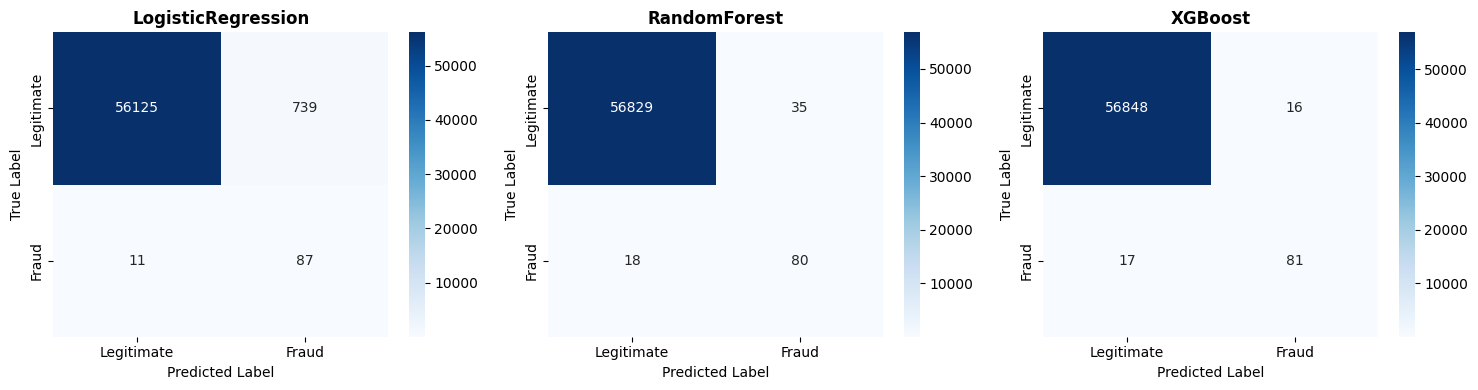

 Confusion matrices show how each model confuses classes


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
print(" Confusion matrices show how each model confuses classes")


FEATURE IMPORTANCE ANALYSIS

 Random Forest Feature Importance (Top 15):
Feature  Importance
    V14    0.284583
     V4    0.160895
    V10    0.111713
    V11    0.101105
     V3    0.078728
    V17    0.057975
     V2    0.047185
    V12    0.041030
    V16    0.033273
    V18    0.021188
    V19    0.012160
     V1    0.011619
     V7    0.007392
    V20    0.006575
     V9    0.005573


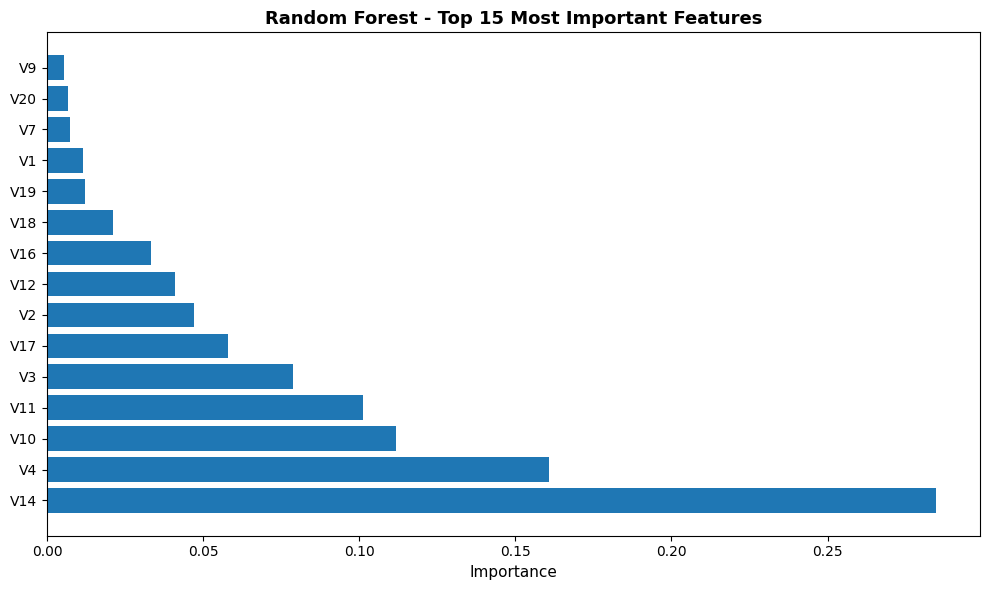


 Feature importance reveals which features matter most for fraud detection

 XGBoost Feature Importance (Top 15):
Feature  Importance
    V14    0.708161
    V10    0.078271
    V17    0.066416
     V4    0.048187
     V1    0.015113
    V11    0.012773
     V3    0.012338
    V16    0.009672
    V12    0.008937
     V9    0.006527
    V20    0.006149
     V7    0.005827
     V5    0.004807
    V18    0.004738
    V21    0.003304


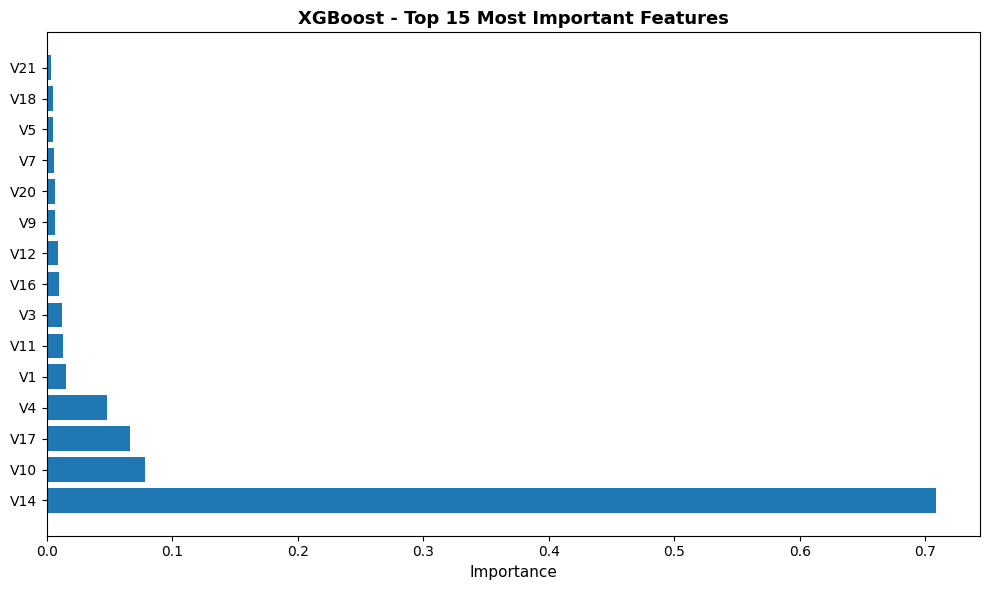

In [36]:

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)


print("\n Random Forest Feature Importance (Top 15):")
rf_importance = models['RandomForest'].feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print(rf_importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(15), rf_importance_df.head(15)['Importance'].values)
plt.yticks(range(15), rf_importance_df.head(15)['Feature'].values)
plt.xlabel('Importance', fontsize=11)
plt.title('Random Forest - Top 15 Most Important Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Feature importance reveals which features matter most for fraud detection")

print("\n XGBoost Feature Importance (Top 15):")
xgb_importance = models['XGBoost'].feature_importances_
xgb_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

print(xgb_importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(15), xgb_importance_df.head(15)['Importance'].values)
plt.yticks(range(15), xgb_importance_df.head(15)['Feature'].values)
plt.xlabel('Importance', fontsize=11)
plt.title('XGBoost - Top 15 Most Important Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Final Thoughts

- **Imbalanced data** requires careful handling; oversampling via SMOTE improved our ability to detect fraud.
- **XGBoost** usually gave the best F1 scores, but check results table above to confirm on your data.
- **Feature importance** plots help identify which anonymized PCA components are most predictive.

From here, you can:

1. Collect more data or engineer new features (e.g. temporal patterns, merchant info).
2. Tune hyperparameters with grid/search or try other algorithms (LightGBM, neural nets).
3. Deploy the chosen model via API, batch job, or embed in a dashboard.

Good luck with your fraud‑detection project! 🚀